# books_sample.json 기초 분석

- 데이터: `data/raw/books_sample.json`
- 목적: 필드 분포, 결측 현황, 주요 통계 파악

In [81]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# OS 자동 감지해서 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux / Colab
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [82]:
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드

In [83]:
pd.set_option('display.max_colwidth', 50)

with open('../data/raw/books_sample.json', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(10)

레코드 수: 103,482
컬럼 수: 15


,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,4000,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],[011002002],NaN,NaN,NaN,NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,15000,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.여전히 주말이면 산을 찾아 가족은...,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,"[여행, 건강/취미]","[015003003, 015003005, 016002010]",51. 전북 정읍 내장산\n52. 서울 노원 수락산\n53. 충북 담양 금수산\n5...,산에 왜 갔지 ? 그 두 번째 이야기\n★ 준비 걸음 : 아빠 노릇 제대로 못했으니...,https://image.aladin.co.kr/product/3917/39/cov...,NaN
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,16000,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],[010006],NaN,NaN,https://image.aladin.co.kr/product/29747/36/co...,NaN
3,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,14000,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설유머 넘치는 문장과...","중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문...",[소설],"[001001003, 001002003, 001003002, 001004003]",1부 태연에 바람이 일다\n서문\n불 꺼진 묘실\n17년 후\n귀하신 견공\n검을 ...,"당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다!\n중국 누적 ...",https://image.aladin.co.kr/product/24410/85/co...,"저 : 천하귀원\n로맨스 소설 사이트 소상서원의 최고 인기 작가, 중국작가협회 회원..."
4,9788966308019,보건프로그램 개발 및 평가,안양희 저,현문사(유해영),2015-06-25,314,25000,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],[025011001],Chapter 1 보건프로그램의 이해\nⅠ. 건강개요\nⅡ. 보건프로그램 개요\nC...,NaN,https://image.aladin.co.kr/product/7456/15/cov...,NaN
5,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",이희준 저,이야기나무,2015-07-07,360,17000,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...","서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",[여행],"[015001004, 015003003]","우리 시장에서 놀까요?\n시장, 이렇게 구분하면 좋아요!\n대전 _ 신세대 친구를 ...",전국에 흩어진 전통시장을\n20대 청춘의 시선으로 기록하다!\n공모전 준비와 스펙 ...,https://image.aladin.co.kr/product/6266/95/cov...,"저자 : 이희준\n대한민국 최초이자 유일한 전통시장 도슨트, 이희준\n매일매일 가슴..."
6,9788971218549,리파이닝 건축 수법 - 건축물의 장수명화를 위한 설계,아오키 시게루 저 / 박진아 역,세진사,2014-05-02,162,22000,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,"[자연/과학, 대학교재/전문서적]","[008004, 025002001]",[리파이닝 포인트 Points of Refining]\n1. 만주소 리파이닝 포인트...,NaN,https://image.aladin.co.kr/product/4072/17/cov...,역자 : 박진아\n한국건설기술연구원 공공건축연구본부 연구원. Refining Arc...
7,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,중국사천대학 저 / 이수진 역 / 멘사수학연구소 감수,씨실과날실,2019-01-30,204,14000,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,[초등학교 참고서],[022011],01 재미있는 방진도 (Ⅰ) 12\n연습문제 01 19\n02 재미있는 방진도 (...,■ 시중에 나와있는 영재교육 교재와 차별화된 학습과정을 통하여 또래 아이들보다 뛰어...,https://image.aladin.co.kr/product/18015/36/co...,NaN
8,9788928306619,우공비 과학 4-1 - 2013,신사고초등콘텐츠연구회,좋은책신사고,2012-11-01,280,12000,- 독자대상 : 초등학교 4학년\n- 구성 : 이론 + 문제\n- 특징 :\n① 풍...,- 독자대상 : 초등학교 4학년\n- 구성 : 이론 + 문제\n- 특징 :\n① 풍...,[초등학교 참고서],[022004],* [진도비법책]\n1. 무게 재기\n2. 지표의 변화\n3. 식물의 한살이\n4....,NaN,https://image.aladin.co.kr/product/2117/35/cov...,NaN
9,9788930081955,사회통계방법론 - SPSS/PC WINDOWS 12.0,최현철 저,나남,2007-07-10,538,24000,"통계학 전공서. 이 책은 χ² , t 검증, 일원변량방법, 다원변량방법, 단순회귀분...","통계학 전공서. 이 책은 χ² , t 검증, 일원변량방법, 다원변량방법, 단순회귀분...","[컴퓨터/IT, 대학교재/전문서적]","[018009, 025002008]",머리말\n제1장 사회과학과 과학적 연구방법\n1. 사회과학방법과 연구대상\n2. 사...,NaN,https://image.aladin.co.kr/product/93/96/cover...,NaN


In [84]:
df[df['author_intro'].notna()]

,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro
3,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,14000,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설유머 넘치는 문장과...","중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문...",[소설],"[001001003, 001002003, 001003002, 001004003]",1부 태연에 바람이 일다\n서문\n불 꺼진 묘실\n17년 후\n귀하신 견공\n검을 ...,"당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다!\n중국 누적 ...",https://image.aladin.co.kr/product/24410/85/co...,"저 : 천하귀원\n로맨스 소설 사이트 소상서원의 최고 인기 작가, 중국작가협회 회원..."
5,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",이희준 저,이야기나무,2015-07-07,360,17000,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...","서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",[여행],"[015001004, 015003003]","우리 시장에서 놀까요?\n시장, 이렇게 구분하면 좋아요!\n대전 _ 신세대 친구를 ...",전국에 흩어진 전통시장을\n20대 청춘의 시선으로 기록하다!\n공모전 준비와 스펙 ...,https://image.aladin.co.kr/product/6266/95/cov...,"저자 : 이희준\n대한민국 최초이자 유일한 전통시장 도슨트, 이희준\n매일매일 가슴..."
6,9788971218549,리파이닝 건축 수법 - 건축물의 장수명화를 위한 설계,아오키 시게루 저 / 박진아 역,세진사,2014-05-02,162,22000,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,"[자연/과학, 대학교재/전문서적]","[008004, 025002001]",[리파이닝 포인트 Points of Refining]\n1. 만주소 리파이닝 포인트...,NaN,https://image.aladin.co.kr/product/4072/17/cov...,역자 : 박진아\n한국건설기술연구원 공공건축연구본부 연구원. Refining Arc...
10,9788956431123,지긋지긋한 아토피 니시건강법으로 치료한다,와타나베 쇼 저,형설(도서출판),2004-10-05,150,6900,인간이 본래 갖고 있는 자연치유력을 강화하기 위해 체질 그 자체를 개선해 가는 것이...,인간이 본래 갖고 있는 자연치유력을 강화하기 위해 체질 그 자체를 개선해 가는 것이...,[건강/취미],[016001001],서장 스테로이드 리바운드에 이긴다\n1. 스테로이드제와 리바운드의 공포\n2. 아토...,NaN,https://image.aladin.co.kr/product/52/5/cover5...,"저 : 와타나베 쇼 (渡邊 正)\n1922년 일본 야마나시현에서 태어나, 홋카이도 ..."
14,9791164840458,하버드 머스트 리드 플래티넘,마이클 포터 등저,매일경제신문사,2019-12-10,0,75000,‘최고’와 ‘최신’ 경영학이 조화를 이루다세상은 변화의 가속도를 더욱 올리고 있다....,‘최고’와 ‘최신’ 경영학이 조화를 이루다\n세상은 변화의 가속도를 더욱 올리고 있...,[경제/경영],[003002002],NaN,NaN,https://image.aladin.co.kr/product/22042/47/co...,등저 : 마이클 포터 (Michael E. Porter)\n미국 하버드 경영대학원의...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103474,9788926866856,욕망의 문제틀로 읽는 현대사회 - 의 인간학 총서 3,고려대 철학연구소 저,한국학술정보,2014-09-25,336,19000,잘 살기 위해서는 욕망에 대한 심층적인 성찰과 균형 잡힌 사유가 필요하다 현대사회를...,잘 살기 위해서는 욕망에 대한 심층적인 성찰과 균형 잡힌 사유가 필요하다\n현대사회...,"[인문, 대학교재/전문서적]","[005003002, 025012008]",머리말\n생태적 미래와 자발적 가난(김형찬)\n1. 자연 동화와 생태적 미래\n2....,NaN,https://image.aladin.co.kr/product/4842/87/cov...,저 자 소 개\n고려대 철학연구소\n이승환\n고려대학교 철학과를 졸업하고 국립대만대...
103475,9791196125424,"차이나는 꿈 차이 나는 꿈 - 좋아 하는 일은 취미로, 잘 할 수 있는 일은 직업으로",박하나,학교사랑마을사랑협동조합,2018-04-14,252,15000,"저자는 창업을 위해 감성, 지성, 인성을 연습했고 언어생활 중 중국어 선택이 가장 ...","저자는 창업을 위해 감성, 지성, 인성을 연습했고 언어생활 중 중국어 선택이 가장 ...","[경제/경영, 자기계발]","[003002004, 004002]",| CONTENTS |\n1. 나에게도 꿈이\n생겼다\n01. 꿈이 없었던 어린시절...,"좋아하는 일은 취미로, 잘 할수 있는 일은 직업으로\n \n차이 나는 꿈으로 차이나...",https://image.aladin.co.kr/product/14309/86/co...,박하나\n저자 : 박하나\n저자 박하나\n\nHANAPARK 대표\n\n중국어를 전...
103476,9788995833155,대한민국 표류기,허지웅 저,수다,2009-01-20,320,13800,"21세기 대한민국을 표류하는 우리들을, 응원합니다이제 갓 서른을 넘긴 저자가 대한민...","21세기 대한민국을 표류하는 우리들을, 응원합니다\n이제 갓 서른을 넘긴 저자가 대...","[시/에세이, 사회/정치]","[002003, 002005007, 007005]",들어가는 말\n작은 사람들의 나라\n고시원으로부터 온 편지 | 고시원 야간 총무 |...,“찌질한 아이돌에서 시대의 아이콘으로”\n허지웅은 이 찌질한 '공익적 도시 빈민'의...,https://image.aladin.co.kr/product/305/8/cover...,"저 : 허지웅\n[필름2.0]과 [프리미어], [GQ] 에서 기자로 일했다. 에세이..."
103477,9788956849621,트레저 헌터 6,무카이 나츠미 글그림,삼양(만화),2005-01-11,192,3000,"보물을 찾는 게 싫은 게 아냐.봐, 지금도 이렇게 두근거리는 걸 하지만!!아버지가 ...","보물을 찾는 게 싫은 게 아냐.\n봐, 지금도 이렇게 두근거리는 걸\n하지만!!\n...",[만화],[020006],NaN,NaN,https://image.aladin.co.kr/product/53/73/cover...,"글그림 : 무카이 나츠미 (Natsumi MuKai,むかい なつみ,迎 夏生)"


## 2. 결측값 현황

In [85]:
def is_missing(val):
    if isinstance(val, list):
      return len(val) == 0
    if isinstance(val, str):
      return val.strip() == ''
    return pd.isna(val)

missing = {col: df[col].apply(is_missing).sum() for col in df.columns}
missing_df = pd.DataFrame({
    '결측 수': missing,
    '결측률(%)': {k: round(v / len(df) * 100, 1) for k, v in missing.items()}
}).sort_values('결측률(%)', ascending=False)

missing_df

,결측 수,결측률(%)
pub_review,55670,53.8
author_intro,37367,36.1
book_index,21581,20.9
ori_cover_s,2009,1.9
cate_depth1,267,0.3
kcid,267,0.3
isbn,0,0.0
price,0,0.0
page,0,0.0
publish_date,1,0.0


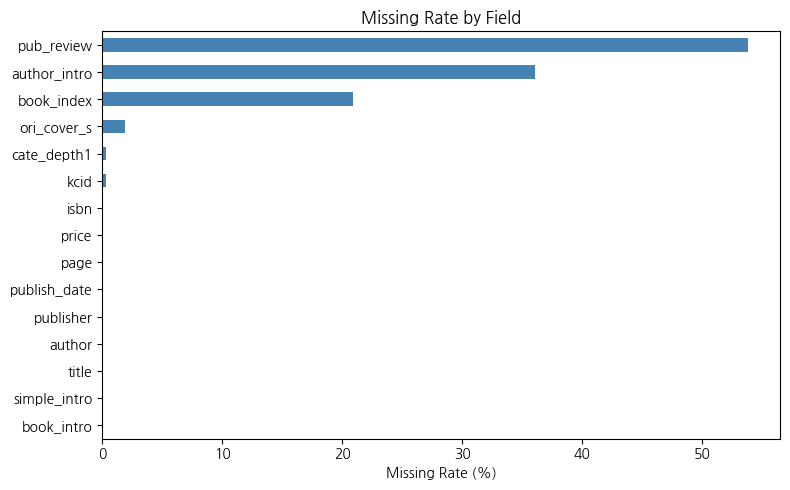

In [86]:
ax = missing_df['결측률(%)'].plot(kind='barh', figsize=(8, 5), color='steelblue')
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Rate by Field')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [87]:
pd.set_option('display.max_colwidth', None)

df_clean = df.dropna()
df_clean.head(5)

isbn  \
3   9788963717715   
5   9791185860084   
15  9788997390205   
16  9788995904961   
17  9791157032068   

                                                            title  \
3                                                          부요황후 1   
5                                 시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주   
15                   Do it! 안드로이드 앱 프로그래밍 - T아카데미의 명강의를 한 권에 담았다!   
16                                           아름다운 마무리 - 법정 스님 산문집   
17  좋아하는 일만 하며 사는 법 - 원하는 삶을 이끌어내는 내 마음대로 사고법 = 「好きなこと」だけして生きて行く。   

          author      publisher publish_date  page  price  \
3   천하귀원 저/김지혜 역    파란썸 (파란미디어)   2020-07-14   420  14000   
5          이희준 저          이야기나무   2015-07-07   360  17000   
15           정재곤        이지스퍼블리싱   2013-06-29   824  40000   
16          법정 저           문학의숲   2008-11-15   246  11500   
17   고코로야 진노스케 저  동양북스(동양books)   2016-11-10   240  13000   

                                                                                                                                                           simple_intro  \
3                  중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설유머 넘치는 문장과 탄탄한 이야기, 끊임없는 상상력이 돋보이는 『부요황후』. 작가 천하귀원에게 2012년 진강시문예상과 전국우수여성문학상을 안긴 『부요황후』는 2018년중국에서 드라마 [부요]로 ...   
5                  서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에 흩어진 435곳의 전통시장을 다니며 기록하면서 언제나 즐거웠던 것만은 아니었지만 지나고 보니 매 순간이 내게 위로였다. 여전히 부끄러운 부분이 많은 글이지만 누군가에게 잘 보이...   
15  젤리빈 4.2.2 버전을 반영한 전면 개정판. T아카데미에서 안드로이드 교육과정을 설계한 명강사, 정재곤 박사가 직접 집필한 책으로, 국내외에서 안드로이드 앱을 개발하고 있는 현업 프로그래머인 저자의 명쾌한 설명을 만날 수 있다. 저자가 직접 강의해주는 동영상(무려 40시간 이상의 분량...   
16                 읽고 또 읽어도 좋다. 법정 스님의 새 산문집!몇 번을 읽어도 항상 새로운 울림과 깨달음을 주는 법정 스님의 산문집. 1년 전, 병으로 삶과 죽음의 경계를 넘나들었던 스님이 우리에게 전하는 메시지는, `삶은 순간순간이 아름다운 마무리이자 새로운 시작이어야 한다...   
17                 수백만 독자의 인생을 바꿔준 성격 리폼 강의“우선, 하기 싫은 일부터 멈춰라!”원하는 삶을 이끌어내는 내 마음대로 사고법읽고 나면 결코 읽기 전의 나로 돌아갈 수 없다상사의 눈치를 보느라 이유 없이 야근하는 직장인들, 부모의 기대에 부응하느라 꿈도 포기한 자식...   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  book_intro  \
3                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문장과 탄탄한 이야기, 끊임없는 상상력이 돋보이는 『부요황후』. 작가 천하귀원에게 2012년 진강시문예상과 전국우수여성문학상을 안긴 『부요황후』는 2018년중국에서 드라마 [부요]로 제작되어 방송 첫날부터 동 시간대 시청률 1위를 달성했다. 주연은 인기 배우 양미(楊?)와 롼징톈(阮經天)이 맡았으며, 누적 조회수 100억 뷰를 돌파해 성공적으로 방영을 마쳤다. 같은 해 한국에서도 드라마 [부요황후]라는 이름으로 방영되어 국내 팬들에게 많은 사랑을 받았다.\n『부요황후』의 주인공 맹부요는 확실한 목표를 정하고 씩씩하게

In [88]:
# 실제 비어있는 데이터 확인
cols = ['pub_review', 'author_intro', 'book_index', 'ori_cover_s', 'cate_depth1', 'kcid', 'publish_date', 'simple_intro']

pd.set_option('display.max_colwidth', 50)
df[df[cols].isna().any(axis=1)].head(20)

,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,4000,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],[011002002],NaN,NaN,NaN,NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,15000,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.여전히 주말이면 산을 찾아 가족은...,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,"[여행, 건강/취미]","[015003003, 015003005, 016002010]",51. 전북 정읍 내장산\n52. 서울 노원 수락산\n53. 충북 담양 금수산\n5...,산에 왜 갔지 ? 그 두 번째 이야기\n★ 준비 걸음 : 아빠 노릇 제대로 못했으니...,https://image.aladin.co.kr/product/3917/39/cov...,NaN
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,16000,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],[010006],NaN,NaN,https://image.aladin.co.kr/product/29747/36/co...,NaN
4,9788966308019,보건프로그램 개발 및 평가,안양희 저,현문사(유해영),2015-06-25,314,25000,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],[025011001],Chapter 1 보건프로그램의 이해\nⅠ. 건강개요\nⅡ. 보건프로그램 개요\nC...,NaN,https://image.aladin.co.kr/product/7456/15/cov...,NaN
6,9788971218549,리파이닝 건축 수법 - 건축물의 장수명화를 위한 설계,아오키 시게루 저 / 박진아 역,세진사,2014-05-02,162,22000,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,"[자연/과학, 대학교재/전문서적]","[008004, 025002001]",[리파이닝 포인트 Points of Refining]\n1. 만주소 리파이닝 포인트...,NaN,https://image.aladin.co.kr/product/4072/17/cov...,역자 : 박진아\n한국건설기술연구원 공공건축연구본부 연구원. Refining Arc...
7,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,중국사천대학 저 / 이수진 역 / 멘사수학연구소 감수,씨실과날실,2019-01-30,204,14000,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,[초등학교 참고서],[022011],01 재미있는 방진도 (Ⅰ) 12\n연습문제 01 19\n02 재미있는 방진도 (...,■ 시중에 나와있는 영재교육 교재와 차별화된 학습과정을 통하여 또래 아이들보다 뛰어...,https://image.aladin.co.kr/product/18015/36/co...,NaN
8,9788928306619,우공비 과학 4-1 - 2013,신사고초등콘텐츠연구회,좋은책신사고,2012-11-01,280,12000,- 독자대상 : 초등학교 4학년\n- 구성 : 이론 + 문제\n- 특징 :\n① 풍...,- 독자대상 : 초등학교 4학년\n- 구성 : 이론 + 문제\n- 특징 :\n① 풍...,[초등학교 참고서],[022004],* [진도비법책]\n1. 무게 재기\n2. 지표의 변화\n3. 식물의 한살이\n4....,NaN,https://image.aladin.co.kr/product/2117/35/cov...,NaN
9,9788930081955,사회통계방법론 - SPSS/PC WINDOWS 12.0,최현철 저,나남,2007-07-10,538,24000,"통계학 전공서. 이 책은 χ² , t 검증, 일원변량방법, 다원변량방법, 단순회귀분...","통계학 전공서. 이 책은 χ² , t 검증, 일원변량방법, 다원변량방법, 단순회귀분...","[컴퓨터/IT, 대학교재/전문서적]","[018009, 025002008]",머리말\n제1장 사회과학과 과학적 연구방법\n1. 사회과학방법과 연구대상\n2. 사...,NaN,https://image.aladin.co.kr/product/93/96/cover...,NaN
10,9788956431123,지긋지긋한 아토피 니시건강법으로 치료한다,와타나베 쇼 저,형설(도서출판),2004-10-05,150,6900,인간이 본래 갖고 있는 자연치유력을 강화하기 위해 체질 그 자체를 개선해 가는 것이...,인간이 본래 갖고 있는 자연치유력을 강화하기 위해 체질 그 자체를 개선해 가는 것이...,[건강/취미],[016001001],서장 스테로이드 리바운드에 이긴다\n1. 스테로이드제와 리바운드의 공포\n2. 아토...,NaN,https://image.aladin.co.kr/product/52/5/cover5...,"저 : 와타나베 쇼 (渡邊 正)\n1922년 일본 야마나시현에서 태어나, 홋카이도 ..."
11,9791193277225,초등 저학년 교과연계 문해력 필독서 세트,편집부 저,춘희네책방,2025-02-18,0,61600,초등학교 1~2학년 교과과정 연계 도서 세트입니다.,초등학교 1~2학년 교과과정 연계 도서 세트입니다.,[어린이],"[012002, 012007001]",『1. 블랙팬서』\n『2. 봄 여름 가을 겨울의 보물찾기』\n『3. 내가 둘이 되었...,『1. 블랙팬서』\n#자신감 #우정 #성장\n국어 2-1 8. 다양한 작품을 감상해...,https://image.aladin.co.kr/product/35898/84/co...,NaN


In [89]:
pd.set_option('display.max_colwidth', None)
df[df['isbn'] == '9791189017057']

,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro
7,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,중국사천대학 저 / 이수진 역 / 멘사수학연구소 감수,씨실과날실,2019-01-30,204,14000,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아드 수학의 지름길시리즈가 2019년을 맞아 국내에 맞추어 최신 신경향 사고력 문제와 국내외 기출문제들을 엮어 새롭게 출간되었다. 기존의 올수지 초급 상·하에서 깊이 다루지 못했던...,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아드 수학의 지름길시리즈가 2019년을 맞아 국내에 맞추어 최신 신경향 사고력 문제와 국내외 기출문제들을 엮어 새롭게 출간되었다. 기존의 올수지 초급 상·하에서 깊이 다루지 못했던 초등학교 사고력과 영재교육과정을 주제별 세분화하여 국내 학생들의 학습에 도움될수 있도록 6년 여간의 수정·보완끝에 초등 영재 수학의 지름길( G&T) 로 선보이게 되었다.,[초등학교 참고서],[022011],01 재미있는 방진도 (Ⅰ) 12\n연습문제 01 19\n02 재미있는 방진도 (Ⅱ) 26\n연습문제 02 31\n03 평균 문제 38\n연습문제 03 42\n04 단위량 문제와 합계 문제 48\n연습문제 04 51\n05 덧셈과 뺄셈 계산하기 56\n연습문제 05 60\n06 곱셈과 나눗셈 계산하기 64\n연습문제 06 70\n07 가로식에 수 넣기 78\n연습문제 07 82\n08 간단한 속력 문제 94\n연습문제 08 96\n09 배의 속력과 합차 문제 98\n연습문제 09 102\n10 나이 문제 106\n연습문제 10 109\n11 같은 우리에 있는 꿩과 토끼 문제 112\n연습문제 11 115\n12 무게 재기와 절약하기 118\n연습문제 12 122\n13 재미있는 추리 130\n연습문제 13 136\n14 소수의 덧셈과 뺄셈 140\n연습문제 14 144\n15 삼각형과 사각형 148\n연습문제 15 156\n별책부록\n연습문제 정답과 풀이,"■ 시중에 나와있는 영재교육 교재와 차별화된 학습과정을 통하여 또래 아이들보다 뛰어난 성취효과를 얻을수 있도록 하였습니다.\n■ 올림피아드뿐만이 아닌 교과심화에 가까운 수학적 사고력을 키우는 문제들로 엄선하여 수록하였습니다.\n■ 연습문제에 있어서도 A형의 기본연습문제 뿐만 아니라 B형의 연습문제(대부분이 최근 중국 2, 3년간 각지역에서 방과 후 활동에 사용한 문제임)도 제공하여 학생들과 교사들이 선택하여 사용할 수 있도록 하였습니다.\n본 시리즈는 편찬과정에서부터 국내 교육에 맞는 최종 감수 및 재구성까지 장기간 초등학교 영재(올림피아드) 수학강의를 하셨던 1급 교사와 특급 교사들이 참여하였습니다. 인생에는 깊이 생각해야 하는 시기가 있고, 사고력을 키우는 것이 공부하는 목적 중의 하나라고 하였습니다. 바꾸어 말하면 지혜의 깊이는 공부를 통해서만이 얻을 수 있습니다. 지혜에는 ‘넓이’가 있고 ‘깊이’가 있고 ‘힘’이 있습니다.‘지혜’는 결단력입니다. 수학은 단순한 문제풀이가 아닌 원리와 사고력이 중요합니다. 다양한 풀이 방법과 사고를 통해 학생 스스로가 문제를 해결해 나가는 습관을 들이는 것이 중요합니다. 문제가 어렵더라도 포기하지 않고 인내와 끈기로 집중력있게 풀고 익히다 보면 어느새 한걸음 더 나아가 있는 모습을 보게 될것입니다. 비록 여러 번의 수정이 있었지만 실력이 부족한 관계로 매끄럽지 않은 부분이 있을 수 있으니 독자여러분들의 기탄없는 지도 편달을 바랍니다. 아울러 나라의 기둥이 되는 대한민국의 축복받은 학생들에게 잠재되어 있는 재능을 발휘하는데 조금이라도 도움이 되길 바라며 시리즈의 출간을 허락해 주신 중국사천대학 출판사의 관계자 여러 분들께 깊은 감사를 드립니다.",https://image.aladin.co.kr/product/18015/36/cover500/k772534741_1.jpg,NaN


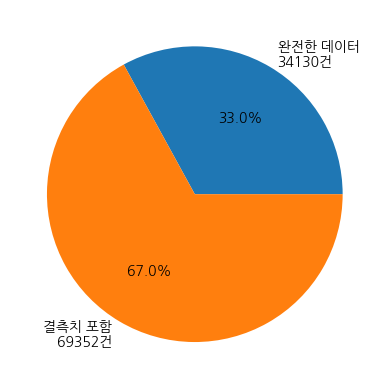

In [90]:
complete = df.dropna().shape[0]
incomplete = len(df) - complete

labels = [f'완전한 데이터\n{complete}건', f'결측치 포함\n{incomplete}건']
sizes = [complete, incomplete]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.show()


## 3. 출판일 분포

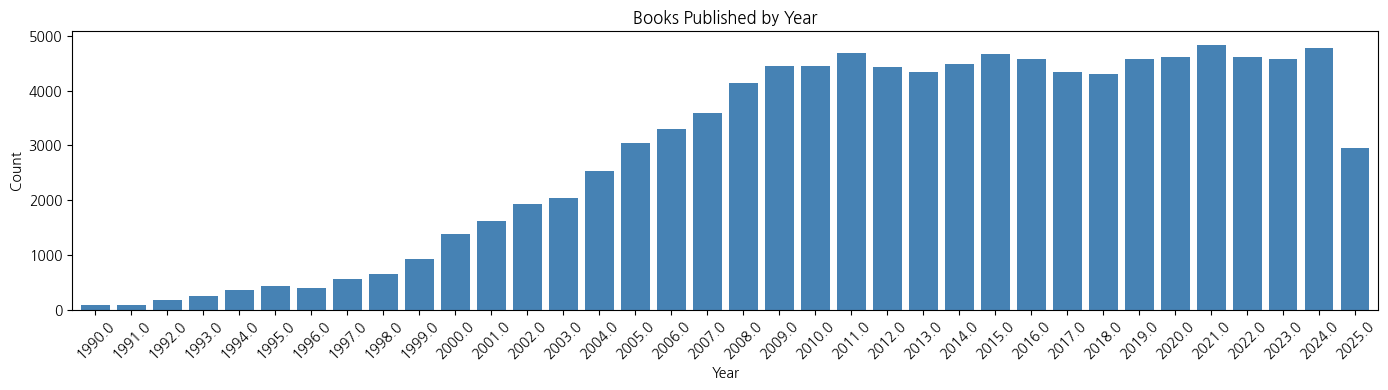

In [91]:
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['publish_year'] = df['publish_date'].dt.year

year_counts = df['publish_year'].value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 1990) & (year_counts.index <= 2025)]

ax = year_counts.plot(kind='bar', figsize=(14, 4), color='steelblue', width=0.8)
ax.set_title('Books Published by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 카테고리(cate_depth1) 분포

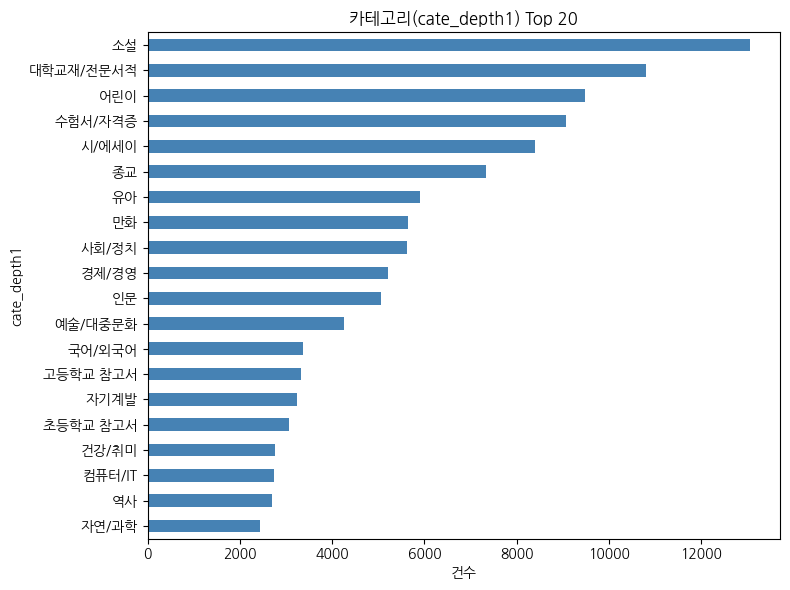

cate_depth1
소설           13056
대학교재/전문서적    10802
어린이           9474
수험서/자격증       9073
시/에세이         8398
종교            7342
유아            5913
만화            5649
사회/정치         5616
경제/경영         5223
인문            5053
예술/대중문화       4269
국어/외국어        3360
고등학교 참고서      3321
자기계발          3239
초등학교 참고서      3062
건강/취미         2758
컴퓨터/IT        2746
역사            2705
자연/과학         2437
Name: count, dtype: int64

In [92]:
cate_series = df['cate_depth1'].explode().dropna()
cate_series = cate_series[cate_series != '']

top_cate = cate_series.value_counts().head(20)
ax = top_cate.plot(kind='barh', figsize=(8, 6), color='steelblue')
ax.set_title('카테고리(cate_depth1) Top 20')
ax.set_xlabel('건수')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_cate

## 5. 텍스트 길이 분포 (simple_intro, book_intro)

In [93]:
df['simple_intro_len'] = df['simple_intro'].fillna('').str.len()
df['book_intro_len'] = df['book_intro'].fillna('').str.len()

df[['simple_intro_len', 'book_intro_len']].describe(percentiles=[.25, .5, .75, .95, .99])

,simple_intro_len,book_intro_len
count,103482.000000,103482.000000
mean,137.955142,349.919184
std,25.964546,282.668875
min,0.000000,1.000000
25%,148.000000,163.000000
50%,148.000000,271.000000
75%,148.000000,461.000000
95%,152.000000,865.000000
99%,166.000000,1287.000000
max,297.000000,11314.000000


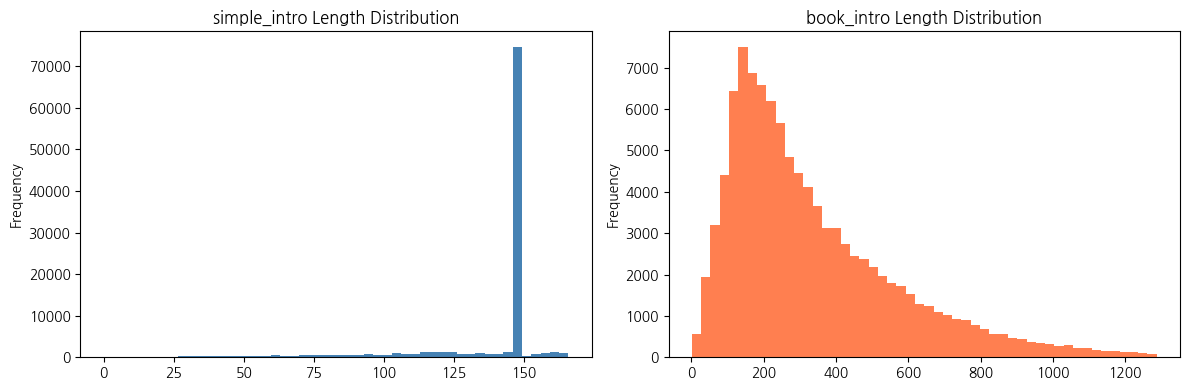

simple_intro 99% truncation 기준 166.0
book_intro 99% truncation 기준 1287.0


In [94]:
# 상위 1% 극단값을 제외하기 위한 99번째 백분위수 계산

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

si_p99 = df['simple_intro_len'].quantile(0.99)
bi_p99 = df['book_intro_len'].quantile(0.99)

df[df['simple_intro_len'] <= si_p99]['simple_intro_len'].plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue'
)
axes[0].set_title('simple_intro Length Distribution')

df[df['book_intro_len'] <= bi_p99]['book_intro_len'].plot(
    kind='hist', bins=50, ax=axes[1], color='coral'
)
axes[1].set_title('book_intro Length Distribution')

plt.tight_layout()
plt.show()

print("simple_intro 99% truncation 기준", si_p99)
print("book_intro 99% truncation 기준", bi_p99)


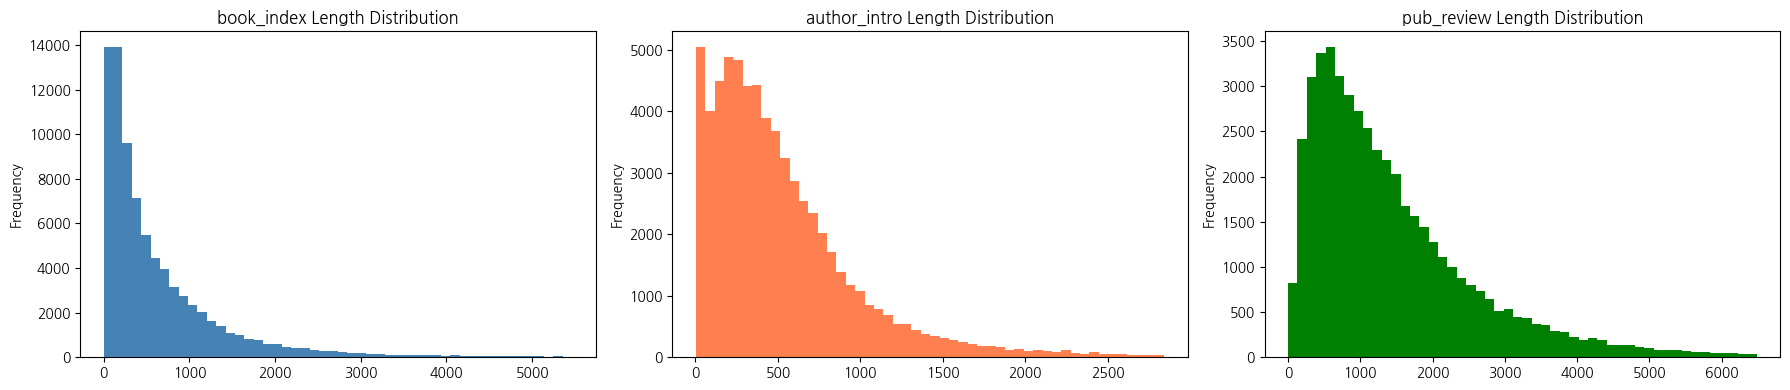

book_index 99% truncation 기준: 5467.0
author_intro 99% truncation 기준: 2844.8600000000006
pub_review 99% truncation 기준: 6485.779999999999


In [95]:
df['book_index_len'] = df['book_index'].str.len()
df['author_intro_len'] = df['author_intro'].str.len()
df['pub_review_len'] = df['pub_review'].str.len()

df[['book_index_len', 'author_intro_len',
'pub_review_len']].describe(percentiles=[.25, .5, .75, .95, .99])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

bi_p99 = df['book_index_len'].quantile(0.99)
ai_p99 = df['author_intro_len'].quantile(0.99)
pr_p99 = df['pub_review_len'].quantile(0.99)

df[df['book_index_len'] <= bi_p99]['book_index_len'].dropna().plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue'
)
axes[0].set_title('book_index Length Distribution')

df[df['author_intro_len'] <= ai_p99]['author_intro_len'].dropna().plot(
    kind='hist', bins=50, ax=axes[1], color='coral'
)
axes[1].set_title('author_intro Length Distribution')

df[df['pub_review_len'] <= pr_p99]['pub_review_len'].dropna().plot(
    kind='hist', bins=50, ax=axes[2], color='green'
)
axes[2].set_title('pub_review Length Distribution')

plt.tight_layout()
plt.show()

print("book_index 99% truncation 기준:", bi_p99)
print("author_intro 99% truncation 기준:", ai_p99)
print("pub_review 99% truncation 기준:", pr_p99)

In [96]:
df['book_index_len'] = df['book_index'].str.len()
df['author_intro_len'] = df['author_intro'].str.len()
df['pub_review_len'] = df['pub_review'].str.len()

df[['book_index_len', 'author_intro_len',
'pub_review_len']].describe(percentiles=[.25, .5, .75, .95, .99])


,book_index_len,author_intro_len,pub_review_len
count,81901.000000,66115.000000,47812.000000
mean,733.297261,560.504333,1504.835188
std,1258.949481,651.916436,1376.074023
min,1.000000,3.000000,1.000000
25%,156.000000,209.000000,604.000000
50%,381.000000,414.000000,1141.000000
75%,867.000000,715.000000,1967.250000
95%,2357.000000,1521.000000,3968.450000
99%,5467.000000,2844.860000,6485.780000
max,32075.000000,31248.000000,44897.000000


In [104]:
cols_to_combine = ['book_intro', 'pub_review']

df['combined_text'] = df[cols_to_combine].fillna('').agg(' '.join,
axis=1).str.strip()
df['combined_len'] = df['combined_text'].str.len()

df[['combined_len']].describe(percentiles=[.25, .5, .75, .95, .99])


,combined_len
count,103482.000000
mean,1045.663294
std,1323.669479
min,1.000000
25%,191.000000
50%,486.000000
75%,1480.000000
95%,3618.950000
99%,5847.000000
max,45155.000000


In [105]:
pd.set_option('display.max_columns', None)
df[df['book_intro_len'] == 50]

,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro,publish_year,simple_intro_len,book_intro_len,book_index_len,author_intro_len,pub_review_len,combined_text,combined_len
3121,9788962896220,"부동산등기법 - 2015,법무사 법원승진 법원 9급 등기사무직렬 시험대비,기출 모의 지문사전",오영관,법학사,2014-11-03,414,25000,- 독자대상 : 법무사/법원승진/법원 9급 등기사무직렬 시험 준비생\n- 구성 : OX문제,- 독자대상 : 법무사/법원승진/법원 9급 등기사무직렬 시험 준비생\n\n- 구성 : OX문제,[수험서/자격증],"[019006001, 019018]",제1편 부동산등기신청절차 일반 \n제1장 총 칙 \n제1절 총 설 \n제2절 부동산등기의 종류 \n제3절 등기할 사항 \n제4절 등기의 효력 \n제5절 등기의 유효요건 \n제2장 등기소와 등기관 \n제1절 등기소 \n제2절 등기관 \n제3장 등기에 관한 장부 \n제1절 등기부 \n제2절 폐쇄등기부 \n제3절 기타의 장부 / 제4절 보존 및 관리 \n제5절 등기부 등 장부의 공개 \n제4장 등기신청절차 일반 \n제1절 서 설 \n제2절 등기신청행위 \n제3절 등기신청당사자능력 \n제4절 전저 (인터넷)등기신청절차 일반 \n제5절 등기신청인 \n제6절 등기신청에 필요한 서면 \n제5장 등기신청에 대한 등기관의 처분 \n제1절 등기신청정보의 입수 \n제2절 등기신청에 대한 심사 \n제3절 등기신청의 취하 \n제4절 등기신청의 각하 \n제5절 등기의 실행 \n제6절 등기완료 후의 절차 \n제7절 등기관의 처분에 대한 이의 \n제2편 각종 등기신청절차 \n제1장 소유권에 관한 등기 \n제1절 소유권보존등기 \n제2절 소유권이전등기 \n제3절 공동소유에 관한 등기 \n제4절 특약에 관한 등기 \n제5절 신탁에 관한 등기 \n제6절 부동산등기실명제와 등기제도 \n제7절 대지권에 관한 등기 \n제2장 소유권 외의 권리에 관한 등기절차 \n제1절 지상권에 관한 등기 \n제2절 지역권에 관한 등기 \n제3절 전세권에 관한 등기 \n제4절 임차권에 관한 등기 \n제5절 근저당권에 관한 등기 \n제6절 동산 채권담보등기 \n제3장 그밖의 각종의 등기절차 \n제1절 변경등기 \n제2절 부동산의 멸실등기 \n제3절 경정등기 \n제4절 말소등기 \n제5절 회복등기 \n제6절 가등기 \n제7절 처분제한의 등기 \n제8절 등기상 이해관계인,NaN,https://image.aladin.co.kr/product/4877/83/cover500/8962896222_1.jpg,NaN,2014.0,49,50,803.0,NaN,NaN,- 독자대상 : 법무사/법원승진/법원 9급 등기사무직렬 시험 준비생\n\n- 구성 : OX문제,50
3353,9788976980090,교회사이야기 - 교회밖에서만나는재미있는,유재덕,호산문화,1996-07-22,326,7200,"교회사 이면에 숨겨진 각종 사건과 일화, 절기에 얽힌이야기와 교회사의 인물들을 소개한 책.","교회사 이면에 숨겨진 각종 사건과 일화, 절기에 얽힌이야기와 교회사의 인물들을 소개한 책.",[종교],[010001],NaN,NaN,https://image.aladin.co.kr/product/1/57/cover500/8976980093_1.jpg,NaN,1996.0,50,50,NaN,NaN,NaN,"교회사 이면에 숨겨진 각종 사건과 일화, 절기에 얽힌이야기와 교회사의 인물들을 소개한 책.",50
4663,9788977670013,누가 나에게 이 길을 가라 하지 않았네1,조호상,연구사,1993-08-01,352,5500,"여성노동자 순영의 삶을 통해 7,80년대 격동의 역사를 조명한 신예작가의 대하노동소설.","여성노동자 순영의 삶을 통해 7,80년대 격동의 역사 를 조명한 신예작가의 대하노동소설.",[소설],[001005],NaN,NaN,NaN,NaN,1993.0,48,50,NaN,NaN,NaN,"여성노동자 순영의 삶을 통해 7,80년대 격동의 역사 를 조명한 신예작가의 대하노동소설.",50
5022,9791165672614,Business English 비즈니스 영어,박효춘 저,주식회사 백산출판사,2021-03-10,360,25000,『Business English 비즈니스 영어』는 비즈니스 영어를 공부할 수 있는 책이다.,『Business English 비즈니스 영어』는 비즈니스 영어를 공부할 수 있는 책이다.,"[국어/외국어, 대학교재/전문서적]","[017002002, 025008004]",UNIT 1\nUNIT 2\nUNIT 3\nUNIT 4\nUNIT 5\nUNIT 6\nUNIT 7\nUNIT 8\nUNIT 9\nUNIT 10\nUNIT 11\nUNIT 12\nUNIT 13\nUNIT 14\nUNIT 15,NaN,https://image.aladin.co.kr/product/26625/18/cover500/k902739238_1.jpg,"저 : 박효춘 (朴孝春)\n영문학박사로 (英) University of Cambridge에서 수학했고 (美) Harvard University를 졸업했다.\n현재 강남대학교 교수, 한국셰익스피어학회 섭외이사, (재)심전국제교류재단 사무국장, 한국 고전르네상스 영문학회 연구이사, 한-카(한국-캐나다)협회 이사이다.",2021.0,50,50,110.0,173.0,NaN,『Business English 비즈니스 영어』는 비즈니스 영어를 공부할 수 있는 책이다.,50
7144,9788972550396,종합 일본어 초급,수곡신자,다락원,1992-07-01,211,9000,교재를 위한 테이프. 주요 대화가 녹음되어 있다. 교재는 별매이다.,<종합 일본어 초급> 교재를 위한 테이프. 주요 대화가 녹음되어 있다. 교재는 별매이다.,[국어/외국어],[017003001],1. 신입사원의 교육\n2. 바코드 소\n3. 고층주택\n4. 불꽃놀이\n5. 수면시간\n6. 골프공\n7. 장미와 지치\n8. 편지\n9. 로봇\n10. 음악\n11. 1회용 나무젓가락\n12. 산과 물고기\n13. 만보기\n14. 쌀\n15. 삿짱,NaN,https://image.aladin.co.kr/product/13/34/cover500/8972550396_1.gif,NaN,1992.0,38,50,126.0,NaN,NaN,<종합 일본어 초급> 교재를 위한 테이프. 주요 대화가 녹음되어 있다. 교재는 별매이다.,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95338,9788969010025,세계행정지도,편집부 편,영진문화사,2013-04-04,1,4000,영진문화사에 출판한 세계행정지도. 각 지역의 특징을 한 눈에 파악하기 용이하도록 제작했다.,영진문화사에 출판한 세계행정지도. 각 지역의 특징을 한 눈에 파악하기 용이하도록 제작했다.,"[어린이, 여행]","[012004002, 015004002]",NaN,NaN,https://image.aladin.co.kr/product/2551/26/cover500/8969010025_1.jpg,NaN,2013.0,50,50,NaN,NaN,NaN,영진문화사에 출판한 세계행정지도. 각 지역의 특징을 한 눈에 파악하기 용이하도록 제작했다.,50
95904,9788904030262,평신도 성경해석지침,월터 헨릭슨 저 / 권달천 역,생명의말씀사,1995-07-30,280,5200,"성경 해석의 원리와 방법, 올바른 성경에의 접근 등 적극적이며 구체적인, 방법론적 지침서.","성경 해석의 원리와 방법, 올바른 성경에의 접근 등 적극적이며 구체적인, 방법론적 지침서.",[종교],[010001],1. 성경 해석 방법\n성경 해석은 모든 사람의 것이다\n일반적 해석 원리\n문법적 해석 원

전체: 103482건
필터링 후: 94544건
제거된 건수: 8938건


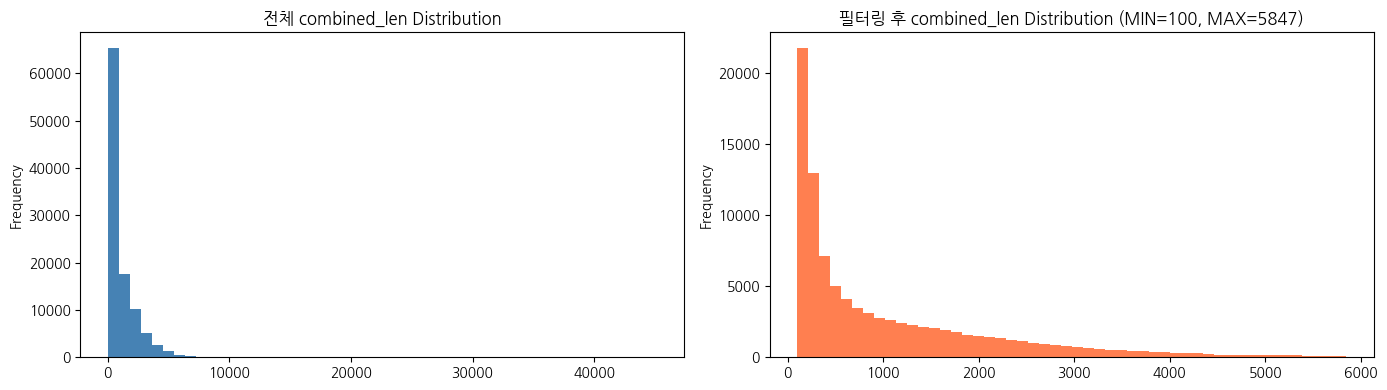

In [111]:
MIN_LEN = 100
MAX_LEN = df['combined_len'].quantile(0.99)

df_filtered = df[(df['combined_len'] >= MIN_LEN) & (df['combined_len'] <=
MAX_LEN)]

print(f"전체: {len(df)}건")
print(f"필터링 후: {len(df_filtered)}건")
print(f"제거된 건수: {len(df) - len(df_filtered)}건")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['combined_len'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('전체 combined_len Distribution')

df_filtered['combined_len'].plot(kind='hist', bins=50, ax=axes[1],
color='coral')
axes[1].set_title(f'필터링 후 combined_len Distribution (MIN={MIN_LEN}, MAX={MAX_LEN:.0f})')

plt.tight_layout()
plt.show()

## 6. 출판사 Top 20

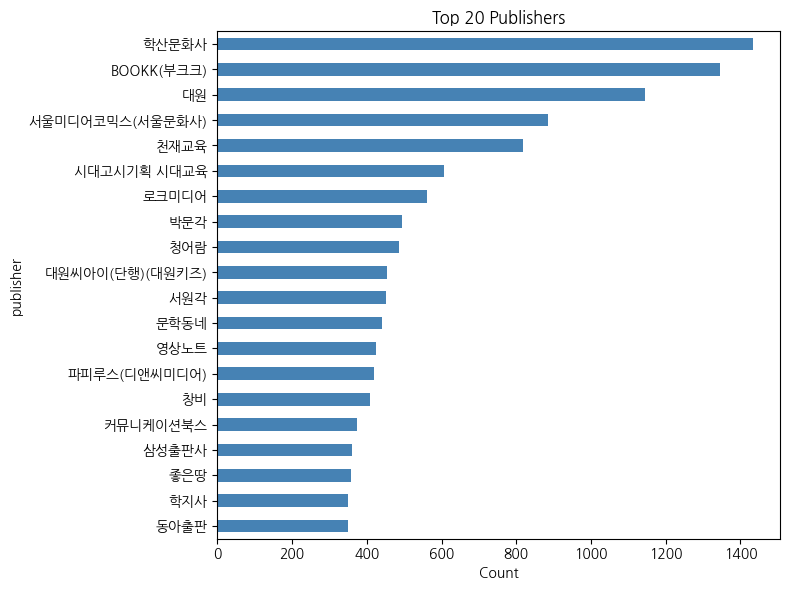

In [64]:
top_pub = df['publisher'].value_counts().head(20)
ax = top_pub.plot(kind='barh', figsize=(8, 6), color='steelblue')
ax.set_title('Top 20 Publishers')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [66]:
# 중복 건수 확인
df['isbn'].duplicated().sum()

# 중복된 행 확인
df[df['isbn'].duplicated(keep=False)].sort_values('isbn')

,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro,publish_year,simple_intro_len,book_intro_len
